In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from smmargins import Margins, Expr
from smmargins.plot import plot_predictions, plot_slopes, plot_comparisons

rng = np.random.default_rng(7)
N = 5_000
df = pd.DataFrame({
    "age":    rng.normal(45, 12, N).clip(18, 90),
    "income": rng.lognormal(10.5, 0.4, N),
    "educ":   rng.choice(["hs", "college", "grad"], N, p=[0.4, 0.4, 0.2]),
    "female": rng.integers(0, 2, N),
})
eta = (-4.0 + 0.05 * df["age"] + 0.00001 * df["income"]
       + 0.8 * (df["educ"] == "college") + 1.4 * (df["educ"] == "grad")
       + 0.3 * df["female"] - 0.0004 * df["age"] * df["female"])
df["voted"] = (rng.uniform(0, 1, N) < 1 / (1 + np.exp(-eta))).astype(int)

fit = smf.logit("voted ~ age + income + C(educ) + female + age:female", data=df).fit(disp=False)
M = Margins(fit)

In [2]:
for pct in [25, 50, 75]:
    res = M.predict(values={"income": f"p{pct}"})
    q_val = float(np.percentile(df["income"], pct))
    print(f"income p{pct} (${q_val:,.0f}): P(vote) = {res.estimate[0]:.4f} "
          f"[{res.ci_lower[0]:.4f}, {res.ci_upper[0]:.4f}]")

income p25 ($27,827): P(vote) = 0.3351 [0.3201, 0.3501]
income p50 ($36,468): P(vote) = 0.3549 [0.3422, 0.3675]
income p75 ($47,304): P(vote) = 0.3803 [0.3664, 0.3943]


In [3]:
income_grid = [float(np.percentile(df["income"], p)) for p in [25, 50, 75]]
res_grid = M.predict(values={"income": income_grid}, default_values="mean")
for lab, est, lo, hi in zip(res_grid.labels, res_grid.estimate, res_grid.ci_lower, res_grid.ci_upper):
    print(f"{lab}: {est:.4f} [{lo:.4f}, {hi:.4f}]")

income=27827.05877072458: 0.3236 [0.3076, 0.3396]
income=36467.642300544954: 0.3445 [0.3310, 0.3581]
income=47303.73775009315: 0.3716 [0.3566, 0.3866]


In [4]:
res_baseline = M.predict()
res_10pct    = M.predict(values={"income": Expr("income * 1.10")})

print(f"Baseline:     {res_baseline.estimate[0]:.4f}")
print(f"+10% income:  {res_10pct.estimate[0]:.4f}")
print(f"Increase:     {res_10pct.estimate[0] - res_baseline.estimate[0]:+.4f}")

Baseline:     0.3622
+10% income:  0.3715
Increase:     +0.0093


In [5]:
joint = M.contrast(a={"female": 1}, b={"female": 0})
print(joint.summary())
# Row 3 (A - B) is the gender gap with the correct joint SE.

                 contrast   std err          z          P>|z|  [95% Conf.  \
A: female=1      0.393371  0.009114  43.161698   0.000000e+00    0.375508   
B: female=0      0.330885  0.008818  37.525278  3.566051e-308    0.313602   
A - B: female=1  0.062486  0.012681   4.927392   8.333442e-07    0.037631   

                 Interval]  
A: female=1       0.411234  
B: female=0       0.348167  
A - B: female=1   0.087341  


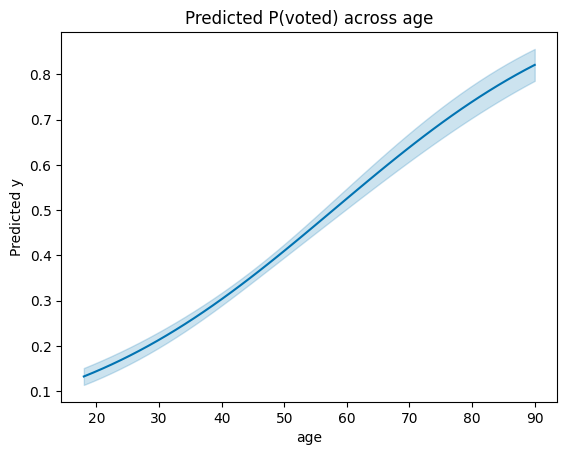

In [6]:
fig, ax = plot_predictions(M, "age")
ax.set_title("Predicted P(voted) across age");

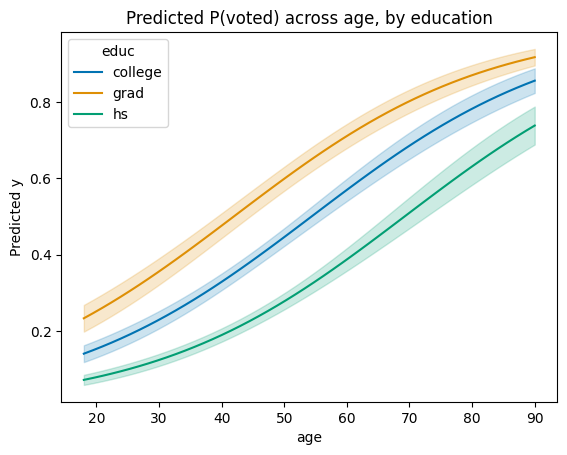

In [7]:
fig, ax = plot_predictions(M, "age", by="educ")
ax.set_title("Predicted P(voted) across age, by education");

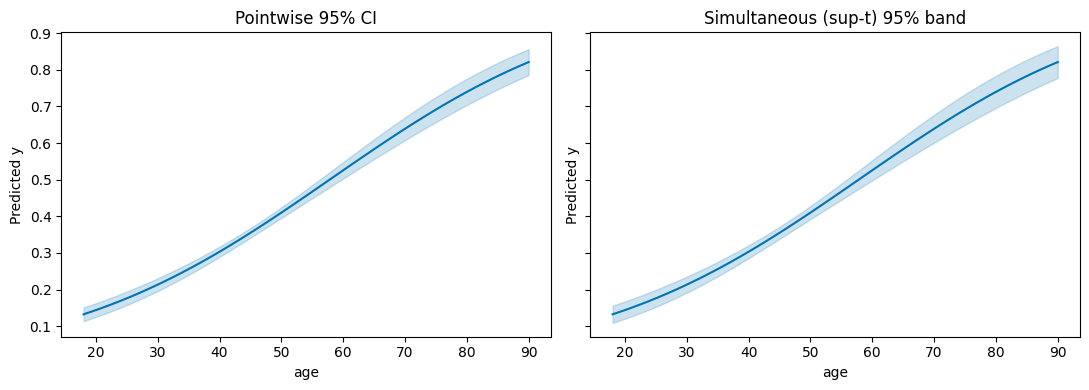

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

plot_predictions(M, "age", ax=axes[0])
axes[0].set_title("Pointwise 95% CI")

plot_predictions(
    M, "age",
    vce="simulation", n_sims=2000, sim_seed=0,
    ci_method="sup-t",
    ax=axes[1],
)
axes[1].set_title("Simultaneous (sup-t) 95% band")
fig.tight_layout();

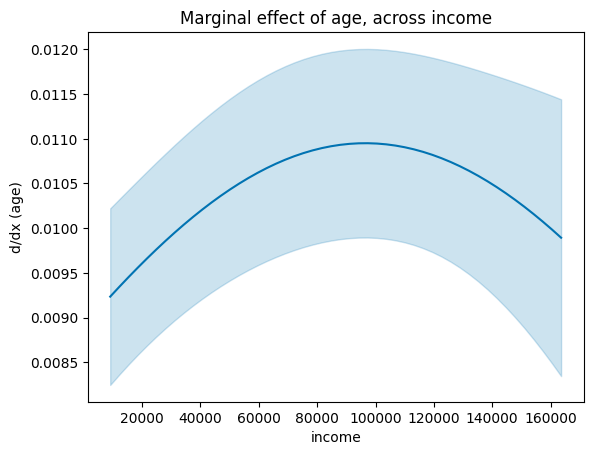

In [9]:
fig, ax = plot_slopes(M, "age", "income")
ax.set_title("Marginal effect of age, across income");

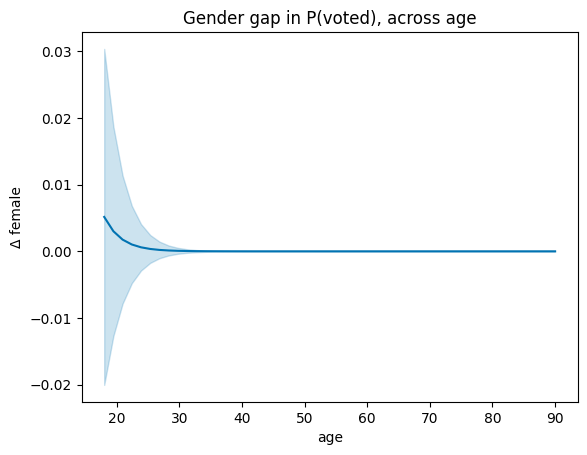

In [10]:
fig, ax = plot_comparisons(M, "female", condition="age")
ax.set_title("Gender gap in P(voted), across age");

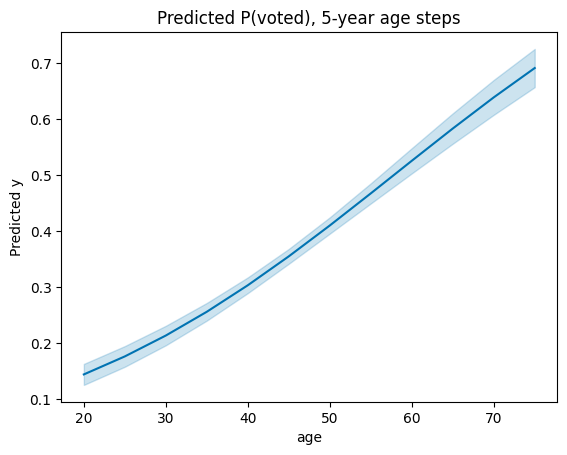

In [11]:
fig, ax = plot_predictions(M, {"age": np.arange(20, 80, 5)})
ax.set_title("Predicted P(voted), 5-year age steps");